# Distributions and Summaries

## Overview

The first step in any analysis is understanding the marginal distribution of each variable before fitting any model.

**What `.describe()` misses:**

| Summary | What it hides |
|---|---|
| Mean | Skew, outliers, multimodality |
| SD | Asymmetry, heavy tails |
| Min/max | Internal outliers, gaps |
| `.describe()` | Distribution shape entirely |

**Plot first, summarise second.** Anscombe's quartet demonstrates that identical summary statistics can describe completely different distributions.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(42)
sns.set_theme(style='whitegrid', palette='muted')

n = 250
sites = pd.DataFrame({
    'site_id':    [f'SITE_{i:03d}' for i in range(1, n+1)],
    'catchment':  rng.choice(['North', 'South', 'East', 'West'], n),
    'elevation':  rng.uniform(50, 400, n).round(1),
    'nitrate':    rng.gamma(2, 2, n).round(2),
    'phosphorus': rng.gamma(1.5, 1.5, n).round(2),
    'ph':         rng.normal(7.2, 0.4, n).round(2),
    'richness':   rng.integers(5, 35, n),
    'treatment':  rng.choice(['control', 'restored'], n),
})
# Introduce a few high-nitrate outliers
sites.loc[rng.choice(n, 6, replace=False), 'nitrate'] += rng.uniform(15, 25, 6)
sites.head()

,site_id,catchment,elevation,nitrate,phosphorus,ph,richness,treatment
0,SITE_001,North,222.9,4.420000,2.35,7.58,12,restored
1,SITE_002,West,165.5,1.280000,0.59,6.59,6,control
2,SITE_003,East,100.6,28.750636,1.66,7.53,7,restored
3,SITE_004,South,86.2,1.630000,0.85,7.36,9,restored
4,SITE_005,South,255.7,6.020000,0.35,6.56,28,restored


---
## Numerical Summaries

In [2]:
numeric_cols = ['elevation', 'nitrate', 'phosphorus', 'ph', 'richness']

summary = sites[numeric_cols].agg([
    'count', 'mean', 'std', 'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max', 'skew',
    lambda x: x.kurt()
]).T
summary.columns = ['n','mean','sd','min','Q1','median','Q3','max','skew','kurt']
print(summary.round(3))

cv = sites[numeric_cols].std() / sites[numeric_cols].mean()
print('\nCoefficient of variation (SD/mean):')
print(cv.round(3))

                n     mean       sd    min       Q1   median       Q3  \
elevation   250.0  222.329  101.744  54.90  131.750  224.100  318.600   
nitrate     250.0    4.513    4.553   0.19    1.812    3.430    5.660   
phosphorus  250.0    2.113    1.577   0.04    0.962    1.745    2.938   
ph          250.0    7.171    0.420   6.02    6.910    7.180    7.428   
richness    250.0   19.360    8.872   5.00   11.250   19.000   28.000   

                max   skew    kurt  
elevation   397.300  0.028  -1.289  
nitrate      33.991  3.293  14.700  
phosphorus    8.790  1.204   1.520  
ph            8.370 -0.079  -0.055  
richness     34.000  0.024  -1.299  

Coefficient of variation (SD/mean):
elevation     0.458
nitrate       1.009
phosphorus    0.746
ph            0.059
richness      0.458
dtype: float64


---
## Histograms with KDE Overlay

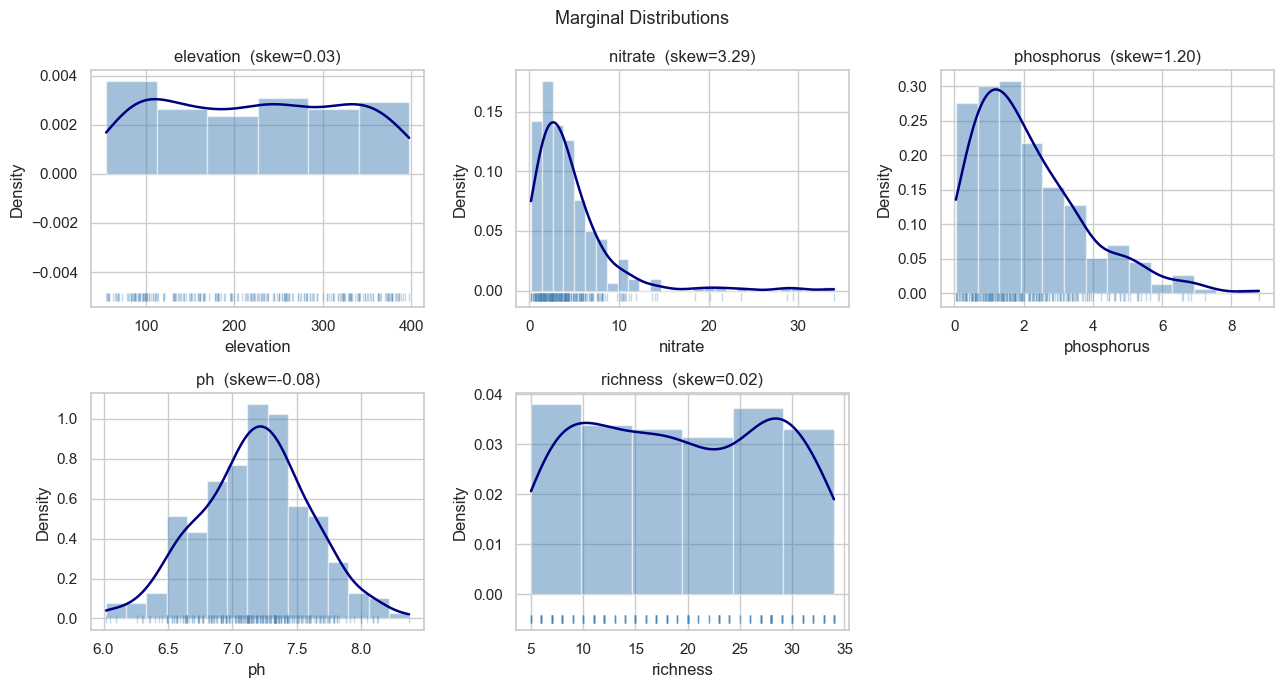

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = sites[col].dropna()
    ax.hist(data, bins='fd', density=True, alpha=0.5,
            color='steelblue', edgecolor='white')
    kde = stats.gaussian_kde(data)
    x_grid = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_grid, kde(x_grid), color='navy', linewidth=1.8)
    ax.plot(data, np.zeros_like(data) - 0.005, '|',
            color='steelblue', alpha=0.3, markersize=6)
    ax.set_title(f'{col}  (skew={data.skew():.2f})')
    ax.set_xlabel(col); ax.set_ylabel('Density')

axes[-1].set_visible(False)
plt.suptitle('Marginal Distributions', fontsize=13)
plt.tight_layout()
plt.show()

---
## Boxplots and Violin Plots by Group

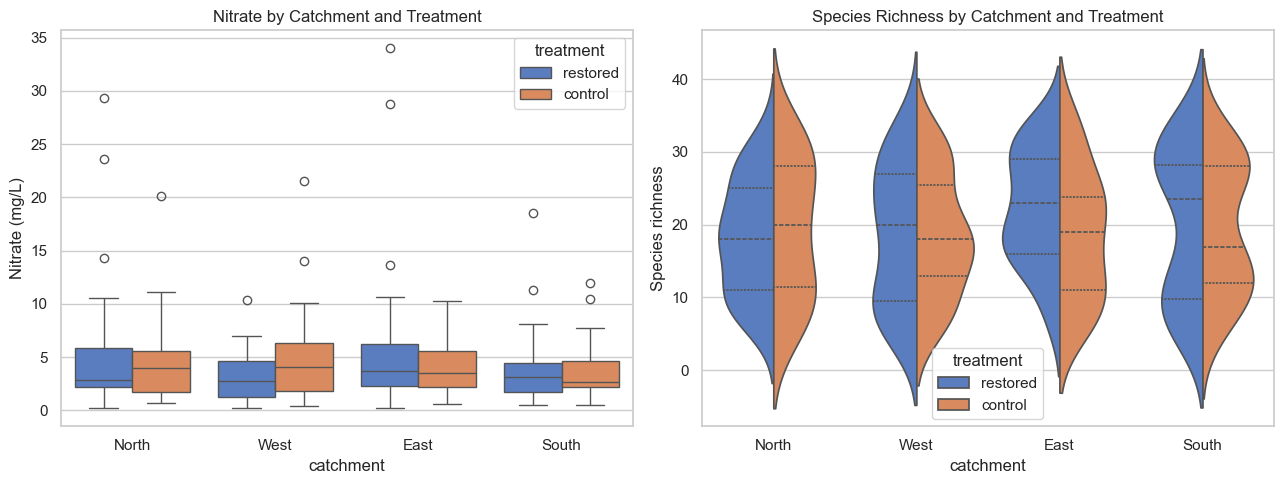

                      mean    std  median  count
catchment treatment                             
East      control    18.60   8.97    19.0     30
          restored   22.18   7.87    23.0     33
North     control    19.17   9.57    20.0     23
          restored   18.21   7.81    18.0     33
South     control    19.36   8.94    17.0     33
          restored   20.08  10.35    23.5     36
West      control    18.49   8.23    18.0     35
          restored   18.48   9.44    20.0     27


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=sites, x='catchment', y='nitrate',
            hue='treatment', ax=axes[0], palette='muted')
axes[0].set_title('Nitrate by Catchment and Treatment')
axes[0].set_ylabel('Nitrate (mg/L)')

# Violin shows full distribution shape — more informative than boxplot alone
sns.violinplot(data=sites, x='catchment', y='richness',
               hue='treatment', split=True, ax=axes[1],
               palette='muted', inner='quart')
axes[1].set_title('Species Richness by Catchment and Treatment')
axes[1].set_ylabel('Species richness')
plt.tight_layout()
plt.show()

print(sites.groupby(['catchment','treatment'])['richness']
      .agg(['mean','std','median','count']).round(2))

---
## Q-Q Plots: Assessing Normality

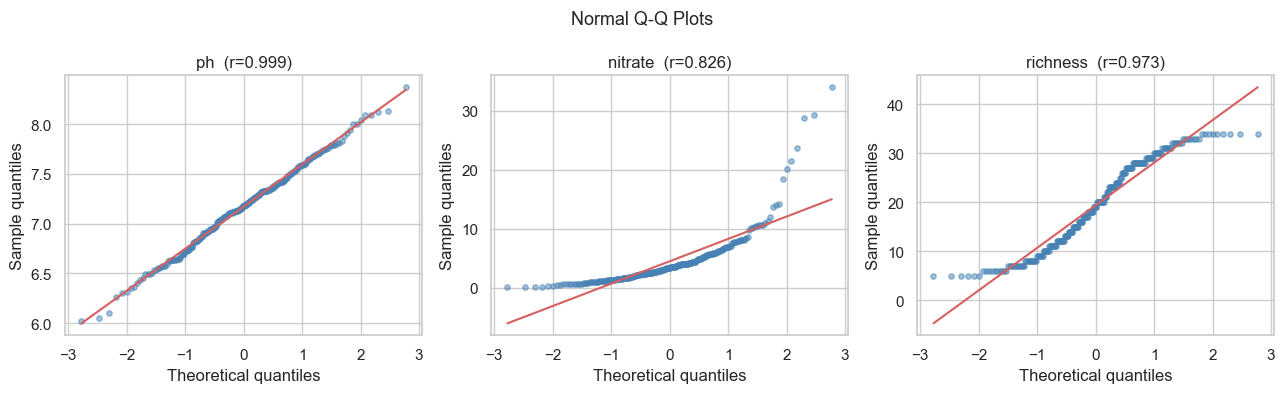

ph          : W=0.9685, p=0.2005
nitrate     : W=0.7035, p=0.0000
richness    : W=0.9352, p=0.0087


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['ph', 'nitrate', 'richness']):
    data = sites[col].dropna().values
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, alpha=0.5, s=15, color='steelblue')
    line_x = np.array([min(osm), max(osm)])
    ax.plot(line_x, slope*line_x + intercept, 'r-', linewidth=1.5)
    ax.set_title(f'{col}  (r={r:.3f})')
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')

plt.suptitle('Normal Q-Q Plots', fontsize=13)
plt.tight_layout()
plt.show()

# Shapiro-Wilk: use only for small n (near-certain rejection at large n)
for col in ['ph', 'nitrate', 'richness']:
    stat, p = stats.shapiro(sites[col].dropna().sample(50, random_state=42))
    print(f'{col:12s}: W={stat:.4f}, p={p:.4f}')

---

## Common Pitfalls

**1. Relying on `.describe()` without plotting**  
Summary statistics can be identical across wildly different distributions. Always plot histograms or density plots before interpreting any numerical summary.

**2. Using the mean to summarise skewed distributions**  
Nitrate and phosphorus concentrations are typically right-skewed. The mean is pulled toward the tail and may not represent any typical observation. Report the median for skewed variables.

**3. Choosing histogram bin width arbitrarily**  
Use `bins='fd'` (Freedman-Diaconis rule) as a data-driven default. Never accept the matplotlib default of 10 bins without checking.

**4. Using Shapiro-Wilk on large samples**  
At n > 100, Shapiro-Wilk detects trivially small departures from normality that are irrelevant in practice. Always inspect the Q-Q plot directly.

**5. Treating boxplot outliers as errors before investigating**  
Points beyond 1.5×IQR are flagged outliers, not necessarily wrong values. In ecological data, extremes often reflect genuine environmental gradients. Always investigate before removing.

---
*python_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*